# 04. Early Stopping — PyTorch

PyTorch has **no built-in EarlyStopping** — you implement it in your loop. That makes the mechanism (watch val loss, keep best weights, stop on patience) completely explicit.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `04_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A training loop with early stopping built in

We track the best test loss, snapshot the weights with `copy.deepcopy`, and break once `patience` epochs pass with no improvement.

In [6]:
import copy

def build_big():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(N_FEATURES, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 1), nn.Sigmoid(),
    )

def train_with_es(model, epochs=300, patience=15, use_es=True):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_loss, best_state, wait, stop_epoch = float("inf"), None, 0, epochs
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); l = loss_fn(model(xb), yb); l.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr, te = model(Xtr), model(Xte)
            vl = loss_fn(te, yte).item()
            hist["loss"].append(loss_fn(tr, ytr).item()); hist["val_loss"].append(vl)
            hist["accuracy"].append((((tr>0.5)==(ytr>0.5)).float().mean()).item())
            hist["val_accuracy"].append((((te>0.5)==(yte>0.5)).float().mean()).item())
        if use_es:
            if vl < best_loss - 1e-4:
                best_loss, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= patience:
                    stop_epoch = epoch + 1
                    break
    if use_es and best_state is not None:
        model.load_state_dict(best_state)        # restore best weights
    return hist, stop_epoch

## 5. Without vs with early stopping

In [7]:
hist_no_es, _   = train_with_es(build_big(), epochs=300, use_es=False)
hist_es, stopped = train_with_es(build_big(), epochs=300, patience=15, use_es=True)
print("No ES : trained full 300 epochs | final test loss = %.4f" % hist_no_es["val_loss"][-1])
print("With ES: stopped at epoch %d | best test loss = %.4f" % (stopped, min(hist_es["val_loss"])))

No ES : trained full 300 epochs | final test loss = 0.6414
With ES: stopped at epoch 60 | best test loss = 0.3944


## 6. Curves side by side

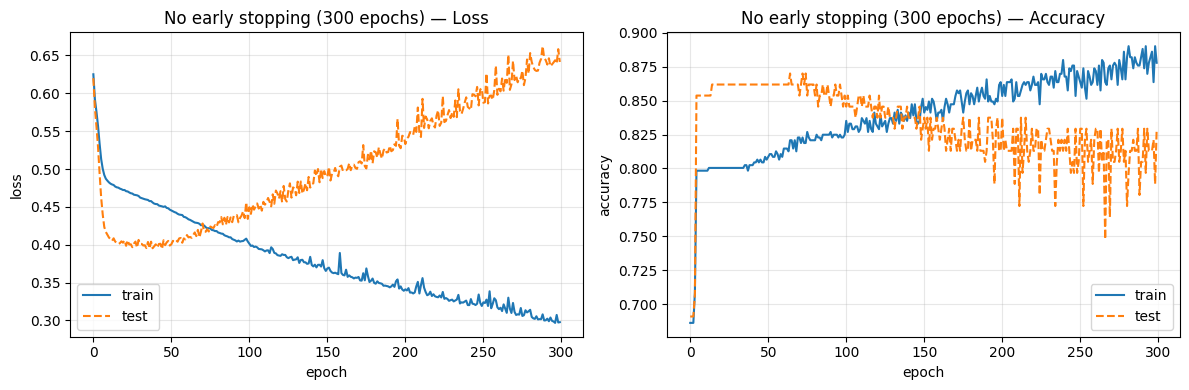

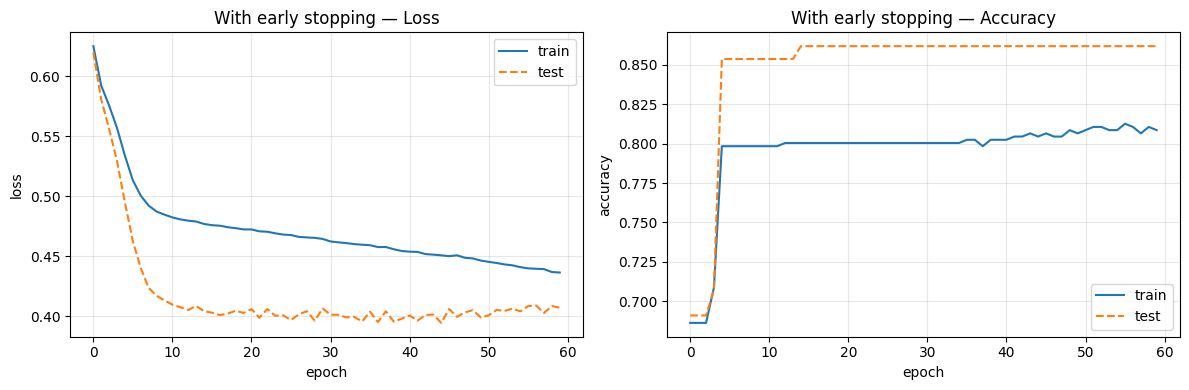

In [8]:
plot_history(hist_no_es, "No early stopping (300 epochs)")
plot_history(hist_es, "With early stopping")

## Takeaways
- Unlike Keras' `EarlyStopping` callback, in PyTorch **you own the loop** — the trade-off is more code but total transparency.
- The three ingredients are always the same: (1) monitor validation loss, (2) remember the best weights, (3) stop after `patience` non-improving epochs.
- `copy.deepcopy(model.state_dict())` is the idiom for snapshotting weights — the equivalent of `restore_best_weights=True`.
- **Next:** `05_grad_clipping_pytorch`.